In [ ]:
# Import neccesary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

# Current Approach in improving performance
 - Remove Outliers
 - Remove high dependent variables
 - Use regularization methods
 - Use deep neural networks
 - check assumption
 - Transform the response variable for stable distribution
 - Create more measures (utilities) from the data (e.g. Star Powers)

In [40]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
parameters_suggested_to_drop_by_RFR = ['production_popular', 'director_score', 'genres_Drama',
       'writer_score', 'month_June', 'genres_Adventure', 'month_December',
       'genres_Comedy', 'genres_Action', 'month_August', 'month_October',
       'month_July', 'month_May', 'month_April', 'genres_Biography',
       'month_November', 'lang_fr', 'month_February', 'month_March',
       'month_September', 'genres_Crime', 'lang_other', 'genres_Horror',
       'month_January', 'lang_ja', 'lang_hi', 'genres_Western', 'has_keywords',
       'genres_Animation', 'genres_Fantasy', 'is_documentary', 'lang_es',
       'genres_Documentary', 'genres_Romance', 'has_trailer', 'genres_War',
       'genres_Thriller', 'genres_Musical', 'genres_Music', 'genres_History',
       'genres_Film-Noir', 'genres_Family', 'genres_Sci-Fi', 'genres_Sport',
       'genres_Mystery', 'genres_Adult', 'titleType_tvMovie',
       'titleType_movie', 'Unnamed: 0', 'name', 'genres', 'directors', 'writers','actors', 'original_language', 'production_companies',
       'release_date','keywords', 'revenue']
X = df.drop(parameters_suggested_to_drop_by_RFR, axis=1)
y_log = np.log1p(y)

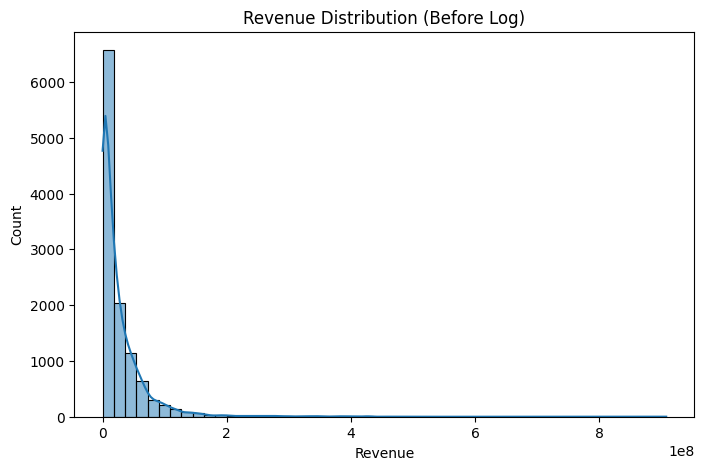

In [41]:
# Check the distribution of the response variable, revenue
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Revenue Distribution (Before Log)")
plt.xlabel("Revenue")
plt.show()

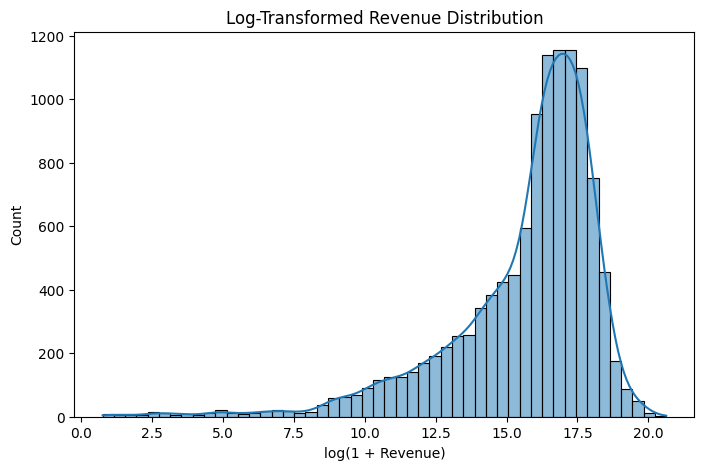

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(y_log, bins=50, kde=True)
plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("log(1 + Revenue)")
plt.show()

In [43]:
# Split original data (no transformation yet)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply log1p to y_train only
y_train_log = np.log1p(y_train)  # Train on log-transformed target

# Scale features using training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
# Check the performance of the dummy variable
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE = np.sqrt(mean_squared_error(y_test, dummy_pred))
R2 = r2_score(y_test, dummy_pred)

# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 41.3 Millions, R²: -0.0


In [45]:
# Check VIF of each variable
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]
print(vif)

             feature        VIF
0      averageRating  22.708094
1           numVotes   1.841326
2             budget   2.407871
3            runtime  21.234849
4      trailer_views   2.729054
5      trailer_likes   3.690759
6        actor_score   1.782771
7            lang_en   4.119690
8  keyword_embedding   1.211220


In [46]:
RFR_tune = RandomForestRegressor()
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],  # Prevents overfitting
    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf
    'max_features': ['sqrt', 'log2', None]  # Feature selection method
}

rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)

# Fit the random search object to the data.
rand_search.fit(X_train, y_train.values.ravel())
rand_search.best_estimator_

Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\psutil\_pswindows.py", line 726, in wrapper
    return fun(self, *args, **kwargs)
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\psutil\_pswindows.py", line 914, in kill
    return cext.proc_kill(self.pid)
           ~~~~~~~~~~~~~~^^^^^^^^^^
PermissionError: [WinError 5] Access is denied: '(originated from OpenProcess)'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\joblib\externals\loky\process_executor.py", line 608, in run
    self.flag_executor_shutting_down()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\joblib\exte

KeyboardInterrupt: 

In [47]:
RFR = RandomForestRegressor(max_features=None, min_samples_leaf=4,
                      min_samples_split=5, n_estimators=300)
RFR.fit(X_train_scaled, y_train.values.ravel())
RMSE = np.sqrt(mean_squared_error(y_test, RFR.predict(X_test_scaled)))
R2 = r2_score(y_test, RFR.predict(X_test_scaled))
# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 28.31 Millions, R²: 0.53


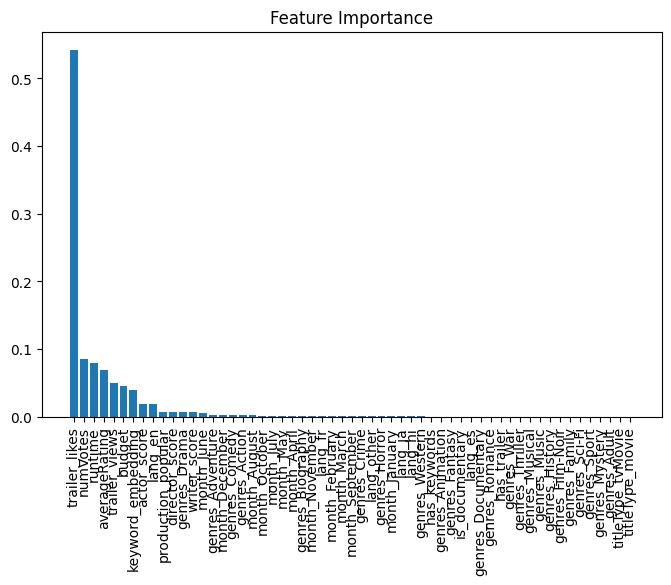

In [36]:
importances = RFR.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(8,5))
plt.title("Feature Importance")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_scaled.shape[1]), X_train.columns[indices], rotation=90)
plt.show()

In [39]:
importances[importances[indices] > 0.01]

array([0.0691665 , 0.08492109, 0.04508278, 0.07913791, 0.05013226,
       0.54212783, 0.        , 0.        , 0.00685104])

In [38]:
X_train.columns[indices]

Index(['trailer_likes', 'numVotes', 'runtime', 'averageRating',
       'trailer_views', 'budget', 'keyword_embedding', 'actor_score',
       'lang_en', 'production_popular', 'director_score', 'genres_Drama',
       'writer_score', 'month_June', 'genres_Adventure', 'month_December',
       'genres_Comedy', 'genres_Action', 'month_August', 'month_October',
       'month_July', 'month_May', 'month_April', 'genres_Biography',
       'month_November', 'lang_fr', 'month_February', 'month_March',
       'month_September', 'genres_Crime', 'lang_other', 'genres_Horror',
       'month_January', 'lang_ja', 'lang_hi', 'genres_Western', 'has_keywords',
       'genres_Animation', 'genres_Fantasy', 'is_documentary', 'lang_es',
       'genres_Documentary', 'genres_Romance', 'has_trailer', 'genres_War',
       'genres_Thriller', 'genres_Musical', 'genres_Music', 'genres_History',
       'genres_Film-Noir', 'genres_Family', 'genres_Sci-Fi', 'genres_Sport',
       'genres_Mystery', 'genres_Adult', 'title